-2.703013450573819172e-12
 3.037799132987044715e+01
 1.215195364662509405e+02
 2.734473507355507991e+02
 4.861992992997493275e+02
 7.598284065739439939e+02
 1.094402869392175944e+03
 1.490006073902721482e+03
 1.946736616168415821e+03
 2.464708326442066664e+03
 3.044050297081189456e+03
 3.684906914060392410e+03

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy.io import wavfile


In [2]:
np.sqrt(1.215195364662509405e+02)/(2*np.pi)


np.float64(1.754458838960662)

In [3]:
11.25

11.25

In [4]:
#open-open
l = 22.5/39.37
v =343
freq = v/(2*l)

In [5]:
l=22.5/39.37
v = 343 #m/s
n=np.array([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29]) # harmonics

freq = (n*v)/(4*l)
lam = (4*l)/n
freq

array([ 150.04344444,  450.13033333,  750.21722222, 1050.30411111,
       1350.391     , 1650.47788889, 1950.56477778, 2250.65166667,
       2550.73855556, 2850.82544444, 3150.91233333, 3450.99922222,
       3751.08611111, 4051.173     , 4351.25988889])

In [6]:
l=22.75/39.37
v = 343 #m/s
n=np.array([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29]) # harmonics

freq = (n*v)/(4*l)
lam = (4*l)/n
freq


array([ 148.39461538,  445.18384615,  741.97307692, 1038.76230769,
       1335.55153846, 1632.34076923, 1929.13      , 2225.91923077,
       2522.70846154, 2819.49769231, 3116.28692308, 3413.07615385,
       3709.86538462, 4006.65461538, 4303.44384615])

In [7]:
#frequency = v/((2*np.pi)*np.sqrt(eigen))

In [8]:
l=((17+(5/16))/39.37)
v = 343 #m/s
n=np.array([1,3,5,7,9,11,13,15,17,19,21,23,25,27,29]) # harmonics
freq = (n*v)/(4*l)
lam = (4*l)/n
freq


array([ 195.00231047,  585.00693141,  975.01155235, 1365.01617329,
       1755.02079422, 2145.02541516, 2535.0300361 , 2925.03465704,
       3315.03927798, 3705.04389892, 4095.04851986, 4485.05314079,
       4875.05776173, 5265.06238267, 5655.06700361])

In [9]:
l

0.439738379476759

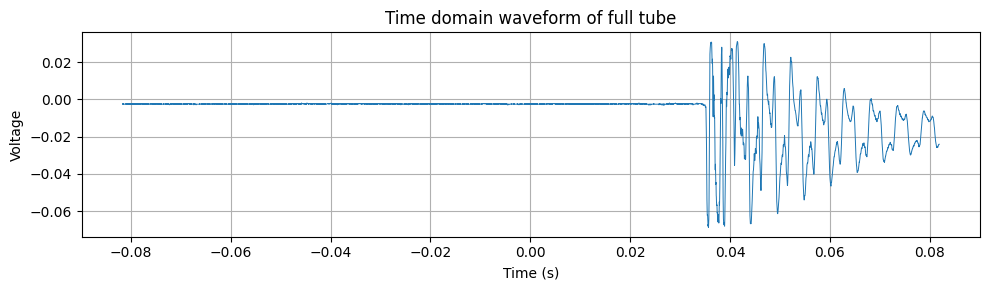

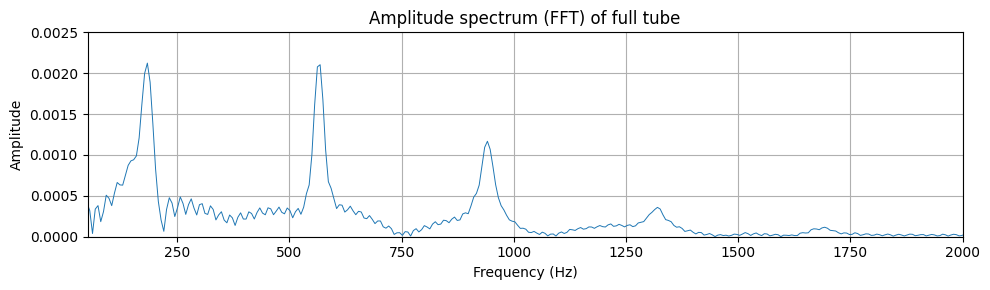

In [10]:
filepath = 'Full_tube.csv'
try:
    df = pd.read_csv(filepath, header=19, encoding='utf-8')
except UnicodeDecodeError:
    # fallback to single-byte encodings if file isn't UTF-8
    for enc in ('latin1', 'cp1252'):
        try:
            df = pd.read_csv(filepath, header=19, encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f"Failed to read {filepath} with utf-8, latin1, or cp1252 encodings")

# Normalize/ensure column names are time,voltage
cols = [c.strip() for c in df.columns]
df.columns = cols
if set(cols) >= {'x', 'y'}:
    df = df.rename(columns={'x': 'time', 'y': 'voltage'})
elif set(cols) >= {'time', 'voltage'}:
    pass
else:
    # fallback: assume first two columns are time and voltage
    df = df.iloc[:, :2]
    df.columns = ['time', 'voltage']

time = df['time'].to_numpy()
voltage = df['voltage'].to_numpy()

# Plot time-domain signal
plt.figure(figsize=(10, 3))
plt.plot(time, voltage, linewidth=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Time domain waveform of full tube')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute FFT
dt = np.mean(np.diff(time))           # sampling interval
fs = 1.0 / dt                         # sampling frequency
N = len(voltage)
yf = np.fft.rfft(voltage)
xf = np.fft.rfftfreq(N, d=dt)
amp = np.abs(yf) / N                  # amplitude spectrum (normalized)

# Plot amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf, amp, linewidth=0.7)
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum (FFT) of full tube')
plt.xlim(50,2000)
plt.ylim(0,0.0025)
plt.grid(True)
plt.tight_layout()
plt.show()

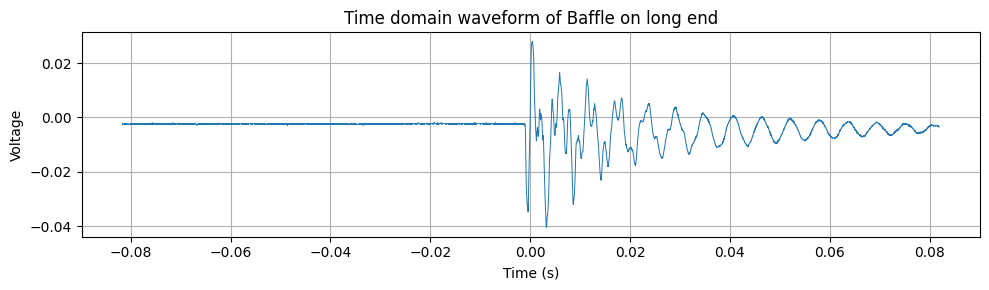

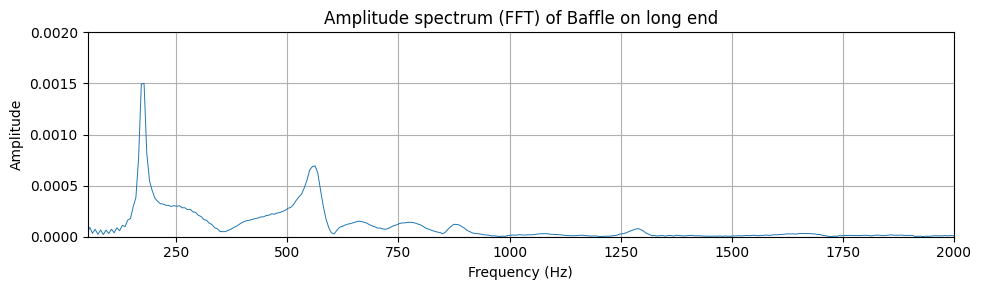

In [11]:
filepath = 'Closed_long_end.csv'
try:
    df = pd.read_csv(filepath, header=19, encoding='utf-8')
except UnicodeDecodeError:
    # fallback to single-byte encodings if file isn't UTF-8
    for enc in ('latin1', 'cp1252'):
        try:
            df = pd.read_csv(filepath, header=19, encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f"Failed to read {filepath} with utf-8, latin1, or cp1252 encodings")

# Normalize/ensure column names are time,voltage
cols = [c.strip() for c in df.columns]
df.columns = cols
if set(cols) >= {'x', 'y'}:
    df = df.rename(columns={'x': 'time', 'y': 'voltage'})
elif set(cols) >= {'time', 'voltage'}:
    pass
else:
    # fallback: assume first two columns are time and voltage
    df = df.iloc[:, :2]
    df.columns = ['time', 'voltage']

time = df['time'].to_numpy()
voltage = df['voltage'].to_numpy()

# Plot time-domain signal
plt.figure(figsize=(10, 3))
plt.plot(time, voltage, linewidth=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Time domain waveform of Baffle on long end')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute FFT
dt = np.mean(np.diff(time))           # sampling interval
fs = 1.0 / dt                         # sampling frequency
N = len(voltage)
yf = np.fft.rfft(voltage)
xf = np.fft.rfftfreq(N, d=dt)
amp = np.abs(yf) / N                  # amplitude spectrum (normalized)

# Plot amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf, amp, linewidth=0.7)
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum (FFT) of Baffle on long end')
plt.xlim(50,2000)
plt.ylim(0,0.002)
plt.grid(True)
plt.tight_layout()
plt.show()

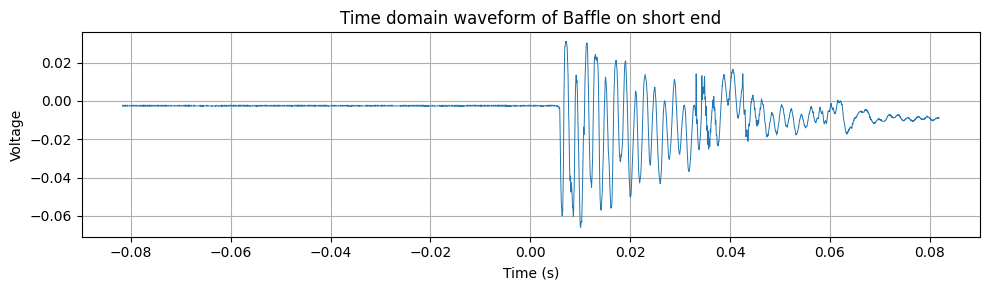

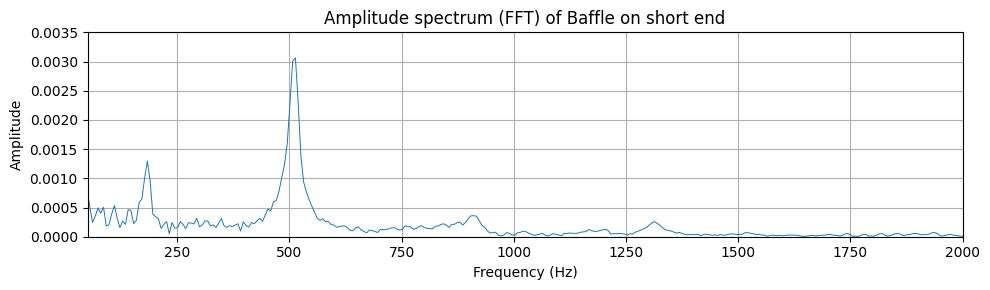

In [12]:
filepath = 'Closed_short_end.csv'
try:
    df = pd.read_csv(filepath, header=19, encoding='utf-8')
except UnicodeDecodeError:
    # fallback to single-byte encodings if file isn't UTF-8
    for enc in ('latin1', 'cp1252'):
        try:
            df = pd.read_csv(filepath, header=19, encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f"Failed to read {filepath} with utf-8, latin1, or cp1252 encodings")

# Normalize/ensure column names are time,voltage
cols = [c.strip() for c in df.columns]
df.columns = cols
if set(cols) >= {'x', 'y'}:
    df = df.rename(columns={'x': 'time', 'y': 'voltage'})
elif set(cols) >= {'time', 'voltage'}:
    pass
else:
    # fallback: assume first two columns are time and voltage
    df = df.iloc[:, :2]
    df.columns = ['time', 'voltage']

time = df['time'].to_numpy()
voltage = df['voltage'].to_numpy()

# Plot time-domain signal
plt.figure(figsize=(10, 3))
plt.plot(time, voltage, linewidth=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Time domain waveform of Baffle on short end')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compute FFT
dt = np.mean(np.diff(time))           # sampling interval
fs = 1.0 / dt                         # sampling frequency
N = len(voltage)
yf = np.fft.rfft(voltage)
xf = np.fft.rfftfreq(N, d=dt)
amp = np.abs(yf) / N                  # amplitude spectrum (normalized)

# Plot amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf, amp, linewidth=0.7)
plt.xlim(0, fs/2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum (FFT) of Baffle on short end')
plt.xlim(50,2000)
plt.ylim(0,0.0035)
plt.grid(True)
plt.tight_layout()
plt.show()

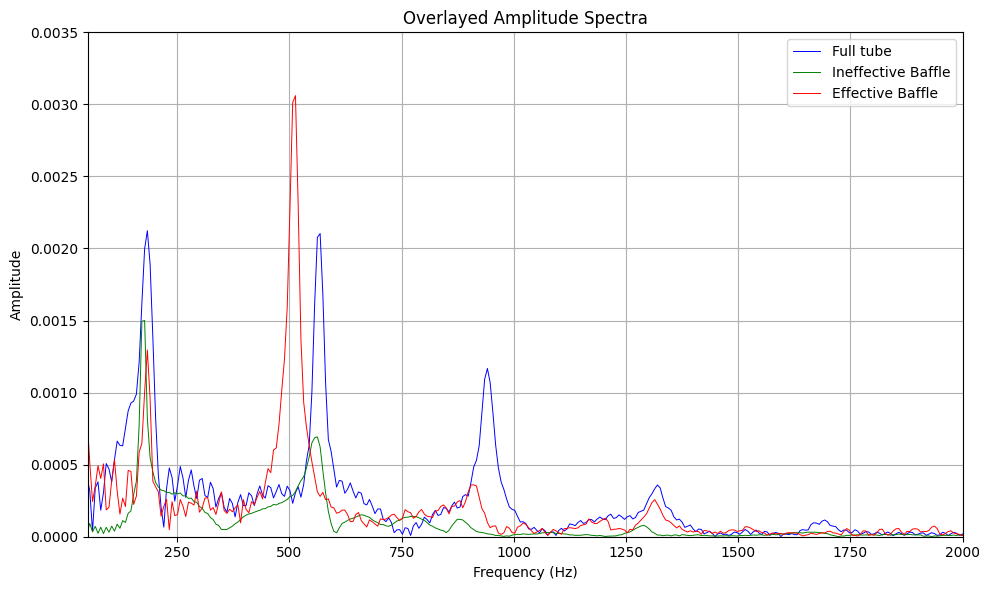

In [13]:
# Load and compute amplitude spectra for all three files
files = ['Full_tube.csv', 'Closed_long_end.csv', 'Closed_short_end.csv']
labels = ['Full tube', 'Ineffective Baffle', 'Effective Baffle']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))

for filepath, label, color in zip(files, labels, colors):
    try:
        df = pd.read_csv(filepath, header=19, encoding='utf-8')
    except UnicodeDecodeError:
        for enc in ('latin1', 'cp1252'):
            try:
                df = pd.read_csv(filepath, header=19, encoding=enc)
                break
            except Exception:
                df = None
        if df is None:
            raise RuntimeError(f"Failed to read {filepath} with utf-8, latin1, or cp1252 encodings")

    cols = [c.strip() for c in df.columns]
    df.columns = cols
    if set(cols) >= {'x', 'y'}:
        df = df.rename(columns={'x': 'time', 'y': 'voltage'})
    elif set(cols) >= {'time', 'voltage'}:
        pass
    else:
        df = df.iloc[:, :2]
        df.columns = ['time', 'voltage']

    time = df['time'].to_numpy()
    voltage = df['voltage'].to_numpy()

    dt = np.mean(np.diff(time))
    N = len(voltage)
    yf = np.fft.rfft(voltage)
    xf = np.fft.rfftfreq(N, d=dt)
    amp = np.abs(yf) / N

    plt.plot(xf, amp, linewidth=0.7, color=color, label=label)

plt.xlim(50, 2000)
plt.ylim(0, 0.0035)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Overlayed Amplitude Spectra')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
import scipy.signal as signal

def load_and_fft(filepath):
    try:
        df = pd.read_csv(filepath, header=19, encoding='utf-8')
    except UnicodeDecodeError:
        for enc in ('latin1', 'cp1252'):
            try:
                df = pd.read_csv(filepath, header=19, encoding=enc)
                break
            except Exception:
                df = None
        if df is None:
            raise RuntimeError(f"Failed to read {filepath} with utf-8, latin1, or cp1252 encodings")

    cols = [c.strip() for c in df.columns]
    df.columns = cols
    if set(cols) >= {'x', 'y'}:
        df = df.rename(columns={'x': 'time', 'y': 'voltage'})
    elif set(cols) >= {'time', 'voltage'}:
        pass
    else:
        df = df.iloc[:, :2]
        df.columns = ['time', 'voltage']

    time = df['time'].to_numpy()
    voltage = df['voltage'].to_numpy()

    dt = np.mean(np.diff(time))
    N = len(voltage)
    yf = np.fft.rfft(voltage)
    xf = np.fft.rfftfreq(N, d=dt)
    amp = np.abs(yf) / N

    return xf, amp

def extract_peak_freqs(xf, amp, ranges, height=1e-4):
    peak_freqs = {}
    for lo, hi in ranges:
        mask = (xf >= lo) & (xf <= hi)
        xf_masked = xf[mask]
        amp_masked = amp[mask]
        peaks, _ = signal.find_peaks(amp_masked, height=height)
        peak_freqs[(lo, hi)] = xf_masked[peaks]
    return peak_freqs

freq_ranges = [(50, 250), (400, 600), (750, 1000), (1100, 1500)]

for filepath, label in zip(files, labels):
    xf, amp = load_and_fft(filepath)
    peaks_by_range = extract_peak_freqs(xf, amp, freq_ranges)

    print(f"{label}:")
    for (lo, hi), freqs in peaks_by_range.items():
        print(f"  {lo}-{hi} Hz: {np.round(freqs, 3)}")
    print()

Full tube:
  50-250 Hz: [ 73.341  91.676 116.123 183.352 232.245]
  400-600 Hz: [409.485 433.932 452.267 476.714 495.05  519.496 568.39 ]
  750-1000 Hz: [800.636 825.083 843.418 867.865 892.311 941.205]
  1100-1500 Hz: [1149.004 1167.339 1191.786 1216.233 1234.568 1259.015 1320.132 1369.026]

Ineffective Baffle:
  50-250 Hz: [128.346 177.24 ]
  400-600 Hz: [464.491 562.278]
  750-1000 Hz: [770.077 873.976]
  1100-1500 Hz: []

Effective Baffle:
  50-250 Hz: [ 73.341  85.564 110.011 128.346 140.57  183.352 226.134 238.357]
  400-600 Hz: [415.597 433.932 452.267 513.385 574.502 586.725]
  750-1000 Hz: [757.854 794.524 843.418 880.088 910.647]
  1100-1500 Hz: [1167.339 1204.009 1314.02 ]



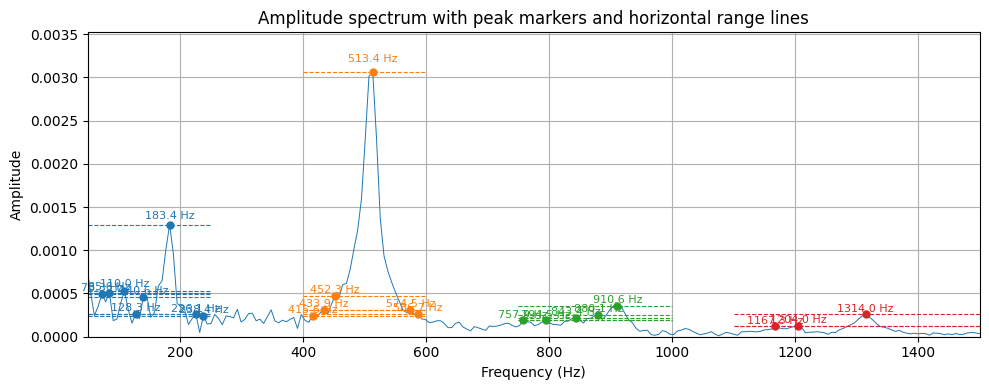

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(xf, amp, linewidth=0.7, label='Amplitude spectrum')

for i, ((lo, hi), freqs) in enumerate(peaks_by_range.items()):
    color = f"C{i}"
    for f in freqs:
        idx = np.argmin(np.abs(xf - f))
        a = amp[idx]
        plt.hlines(a, lo, hi, color=color, linestyles='--', linewidth=0.8)
        plt.plot(f, a, marker='o', color=color, markersize=5)
        plt.text(f, a * 1.03, f"{f:.1f} Hz", fontsize=8, ha='center', va='bottom', color=color)

plt.xlim(50, 1500)
plt.ylim(0, amp[(xf >= 50) & (xf <= 1500)].max() * 1.15)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Amplitude spectrum with peak markers and horizontal range lines')
plt.grid(True)
plt.tight_layout()
plt.show()